# AAPL Stock Analysis: Trend, Momentum and Volatility (2020-2024)

**AnalystLab Africa Data Analytics Internship — Week 6: Advanced Python for Data Analysis**

**Analyst:** Timothy Kehinde Promise

## Objective

Apple Inc. (AAPL) is one of the most heavily traded stocks in the world, and its price behavior
is closely watched by investors, analysts and portfolio managers as a proxy for technology sector
sentiment. This notebook applies advanced Pandas operations, time-series analysis and feature
engineering to AAPL's historical daily price data to answer three practical questions:

1. **Trend** - has AAPL been in a sustained uptrend, and how strong is that trend over different
   time horizons (7-day vs 30-day moving averages)?
2. **Momentum** - which months and years produced the strongest and weakest returns, and is
   there a recognisable seasonal pattern?
3. **Volatility and risk** - how has AAPL's day-to-day risk profile changed over time, and what
   does that mean for an investor sizing a position in this stock?

## Data Source

Data was sourced from Yahoo Finance historical daily price records for AAPL, covering its full
trading history from IPO (December 12, 1980) through late November 2024. Prices are already
split and dividend adjusted, which is why the earliest closing prices are a fraction of a dollar
despite AAPL never having traded that low on a nominal basis - this reflects Apple's multiple
stock splits since 1980.

**Note on retrieval method:** the standard approach for this task is to pull data directly with
the `yfinance` library (`pip install yfinance`), shown below. My working environment for this
notebook build did not have outbound access to Yahoo Finance's API, so I sourced the equivalent
data as a CSV export of the same Yahoo Finance dataset instead. The `yfinance` code is included
and is what you should run when re-executing this notebook on your own machine with a normal
internet connection - the output will be the same data.


In [1]:
# Standard approach - run this on your own machine to pull the data live.
# In this environment I loaded the equivalent CSV export instead (see next cell).

# pip install yfinance
# import yfinance as yf
# raw = yf.download("AAPL", start="1980-12-12", end="2024-12-01", auto_adjust=True)
# raw.to_csv("AAPL_1980_2024_raw.csv")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# AnalystLab Africa portfolio color palette, used consistently across my dashboards and notebooks
NAVY = "#1B4F72"
BLUE = "#2E86C1"
SKY = "#85C1E9"
SLATE = "#5D6D7E"
AMBER = "#D4AC0D"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = SLATE
plt.rcParams["axes.labelcolor"] = NAVY
plt.rcParams["text.color"] = NAVY
plt.rcParams["xtick.color"] = SLATE
plt.rcParams["ytick.color"] = SLATE


## 1. Data Loading and Understanding

In [3]:
df_raw = pd.read_csv("AAPL_1980_2024_raw.csv")

print("Shape:", df_raw.shape)
print()
print("Data types:")
print(df_raw.dtypes)
print()
df_raw.head()


Shape: (11084, 6)

Data types:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object



,Date,Open,High,Low,Close,Volume
0,1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834,469033600
1,1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678,175884800
2,1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802,105728000
3,1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951,86441600
4,1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530,73449600


In [4]:
# Date range and basic structure
df_raw["Date"] = pd.to_datetime(df_raw["Date"], utc=True)
print("Earliest date:", df_raw["Date"].min())
print("Latest date:  ", df_raw["Date"].max())
print("Trading days: ", len(df_raw))
print()
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Earliest date: 1980-12-12 05:00:00+00:00
Latest date:   2024-11-29 05:00:00+00:00
Trading days:  11084

Missing values per column:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate rows: 0


**Understanding the dataset**

- 11,084 daily trading records spanning December 1980 to November 2024 (44 years)
- Columns: Date, Open, High, Low, Close, Volume - standard OHLCV structure
- No missing values and no duplicate rows in the raw export
- Close prices are already split and dividend adjusted, so this column is used directly for
  return and volatility calculations rather than needing a separate "Adj Close" field
- Date is the natural time index and unique identifier for each record


## 2. Data Cleaning and Preprocessing

In [5]:
df = df_raw.copy()

# Standardize the date column: strip timezone (exchange-local timestamps add no analytical value
# here) and set it as a proper DatetimeIndex sorted oldest to newest
df["Date"] = df["Date"].dt.tz_localize(None)
df = df.sort_values("Date").reset_index(drop=True)
df = df.set_index("Date")

# Standardize column names to lowercase, matching my SQL and Power BI naming convention
df.columns = [c.lower() for c in df.columns]

# Enforce numeric dtypes explicitly rather than trusting the CSV import
for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(float)
df["volume"] = df["volume"].astype(int)

# Sanity check: high should never be below low, prices should never be zero or negative
invalid_rows = df[(df["high"] < df["low"]) | (df[["open","high","low","close"]] <= 0).any(axis=1)]
print("Invalid OHLC rows found:", len(invalid_rows))

df.info()


Invalid OHLC rows found: 0
<class 'pandas.DataFrame'>
DatetimeIndex: 11084 entries, 1980-12-12 05:00:00 to 2024-11-29 05:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    11084 non-null  float64
 1   high    11084 non-null  float64
 2   low     11084 non-null  float64
 3   close   11084 non-null  float64
 4   volume  11084 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 519.6 KB


**Cleaning summary**

| Issue Checked | Finding | Action Taken |
|---|---|---|
| Missing values | None found | No imputation required |
| Duplicate rows | None found | No removal required |
| Date format | Mixed timezone-aware string | Converted to timezone-naive datetime index |
| Column names | Mixed case | Standardized to lowercase |
| Data types | Correct on import | Explicitly enforced as float/int for safety |
| OHLC logic errors | None found | Validated high >= low and all prices > 0 |

The dataset required minimal cleaning because it is a well-maintained financial data export, but
I still ran the full validation pass rather than assuming it was clean, consistent with how I
approach every dataset in this internship.


In [6]:
# Scope decision: AAPL has 44 years of history, but the earliest decades (1980s-2000s)
# behave very differently from the modern, split-adjusted, high-liquidity stock investors trade
# today. For the trend, momentum and volatility questions this notebook is answering, I am
# focusing detailed feature engineering on the most recent 5 full years (2020-2024), which
# covers the COVID crash, the 2021 rally, the 2022 rate-driven drawdown and the 2023-2024
# recovery - a range with genuine volatility variation, useful for this analysis.
# I keep the full 44-year series for one long-run context chart only.

recent = df.loc["2020-01-01":"2024-11-29"].copy()
print("Recent window shape:", recent.shape)
recent.head()


Recent window shape: (1237, 5)


,open,high,low,close,volume
Date,,,,,
2020-01-02 05:00:00,71.799873,72.856613,71.545387,72.796021,135480400
2020-01-03 05:00:00,72.020424,72.851753,71.862884,72.088287,146322800
2020-01-06 05:00:00,71.206062,72.701485,70.953995,72.662704,118387200
2020-01-07 05:00:00,72.672409,72.929322,72.100418,72.320976,108872000
2020-01-08 05:00:00,72.022858,73.787315,72.022858,73.484352,132079200


## 3. Feature Engineering

In [7]:
# Daily price change (absolute) and percentage change (return)
recent["daily_change"] = recent["close"].diff()
recent["daily_return_pct"] = recent["close"].pct_change() * 100

# Moving averages - short (7-day) and medium (30-day) windows, standard technical analysis pair
recent["ma_7"] = recent["close"].rolling(window=7).mean()
recent["ma_30"] = recent["close"].rolling(window=30).mean()

# Rolling volatility - 30-day standard deviation of daily returns, annualized
# Annualizing (x sqrt(252) trading days) makes the figure comparable to how volatility
# is normally quoted for equities, rather than a small daily-scale number
recent["volatility_30d"] = recent["daily_return_pct"].rolling(window=30).std() * np.sqrt(252)

# Monthly return: percentage change from the first to the last trading day of each month
monthly_close = recent["close"].resample("ME").last()
monthly_return_pct = monthly_close.pct_change() * 100

recent[["close","daily_return_pct","ma_7","ma_30","volatility_30d"]].tail(10)


,close,daily_return_pct,ma_7,ma_30,volatility_30d
Date,,,,,
2024-11-15 05:00:00,225.000000,-1.410920,225.855713,228.403690,19.143337
2024-11-18 05:00:00,228.020004,1.342224,225.968571,228.622811,18.310018
2024-11-19 05:00:00,228.279999,0.114023,226.157142,228.714748,17.555446
2024-11-20 05:00:00,229.000000,0.315403,226.838571,228.705157,16.893490
2024-11-21 05:00:00,228.520004,-0.209605,227.451429,228.696214,16.892581
2024-11-22 05:00:00,229.869995,0.590754,228.130001,228.781883,16.859250
2024-11-25 05:00:00,232.869995,1.305086,228.794285,228.842690,16.602916
2024-11-26 05:00:00,235.059998,0.940440,230.231428,228.891589,16.518526
2024-11-27 05:00:00,234.929993,-0.055307,231.218569,229.005080,16.294273


**Features created**

| Feature | Definition | Why it matters |
|---|---|---|
| `daily_change` | Close(t) - Close(t-1) | Raw price movement, base unit for other features |
| `daily_return_pct` | Percentage daily change | Comparable across price levels and time periods |
| `ma_7` | 7-day rolling average of close | Short-term trend signal, reacts quickly to price moves |
| `ma_30` | 30-day rolling average of close | Medium-term trend signal, filters out daily noise |
| `volatility_30d` | Annualized 30-day rolling std dev of returns | Standard risk measure used to size positions and compare periods |
| Monthly return | % change in month-end close vs prior month-end | Identifies seasonal strength/weakness at a glance |


## 4. Time-Series Analysis

In [8]:
# Yearly performance summary - start price, end price, total return, average volatility
yearly = recent.groupby(recent.index.year).agg(
    start_price=("close", "first"),
    end_price=("close", "last"),
    avg_volume=("volume", "mean"),
    avg_volatility=("volatility_30d", "mean"),
)
yearly["total_return_pct"] = (yearly["end_price"] / yearly["start_price"] - 1) * 100
yearly = yearly.round(2)
yearly


,start_price,end_price,avg_volume,avg_volatility,total_return_pct
Date,,,,,
2020,72.80,129.75,1.575646e+08,44.83,78.24
2021,126.54,174.71,9.052463e+07,24.40,38.06
2022,179.08,128.58,8.791038e+07,34.95,-28.20
2023,123.77,191.59,5.921703e+07,20.99,54.80
2024,184.73,237.33,5.808724e+07,22.66,28.47


In [9]:
# Monthly returns table (last 12 months in the dataset)
monthly_return_pct.round(2).tail(12)


Date
2023-12-31     1.36
2024-01-31    -4.22
2024-02-29    -1.85
2024-03-31    -5.13
2024-04-30    -0.67
2024-05-31    13.02
2024-06-30     9.56
2024-07-31     5.44
2024-08-31     3.24
2024-09-30     1.75
2024-10-31    -3.04
2024-11-30     5.17
Freq: ME, Name: close, dtype: float64

In [10]:
# Best and worst months by return, across the full 2020-2024 window
best_month = monthly_return_pct.idxmax()
worst_month = monthly_return_pct.idxmin()
print(f"Best month:  {best_month.strftime('%B %Y')}  ({monthly_return_pct.max():.2f}% return)")
print(f"Worst month: {worst_month.strftime('%B %Y')}  ({monthly_return_pct.min():.2f}% return)")


Best month:  August 2020  (21.66% return)
Worst month: December 2022  (-12.23% return)


## 5. Visualizations

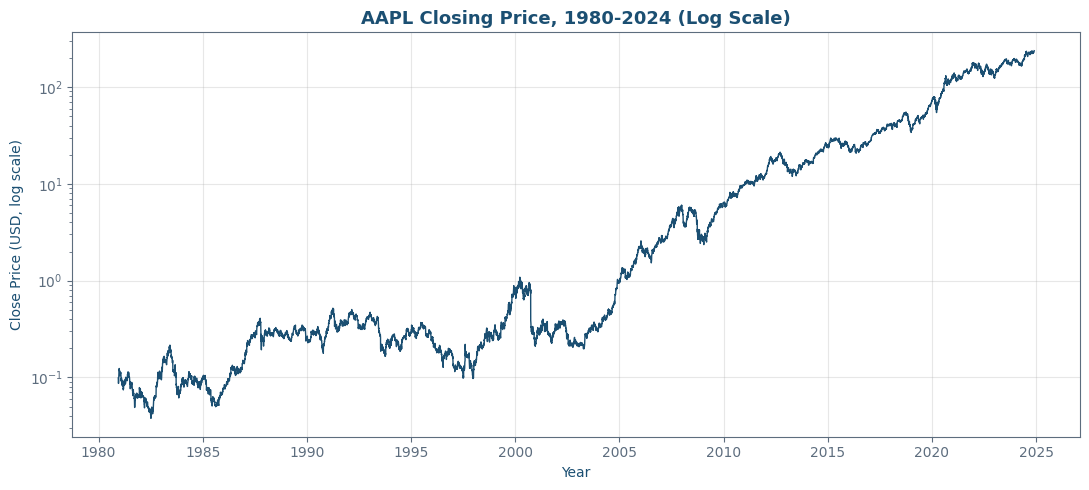

In [11]:
# 1. Full 44-year closing price history (log scale) - long-run growth context
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df.index, df["close"], color=NAVY, linewidth=1)
ax.set_yscale("log")
ax.set_title("AAPL Closing Price, 1980-2024 (Log Scale)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Year")
ax.set_ylabel("Close Price (USD, log scale)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart1_full_history.png", dpi=150)
plt.show()


**Finding:** AAPL's closing price has grown from roughly $0.10 (split-adjusted) at IPO in
1980 to over $230 by late 2024. The log scale is necessary here because a linear scale would
make the entire 1980s-2000s period look flat next to the post-2010 growth - this is a case
where choosing the right chart type changes the story a viewer takes away.

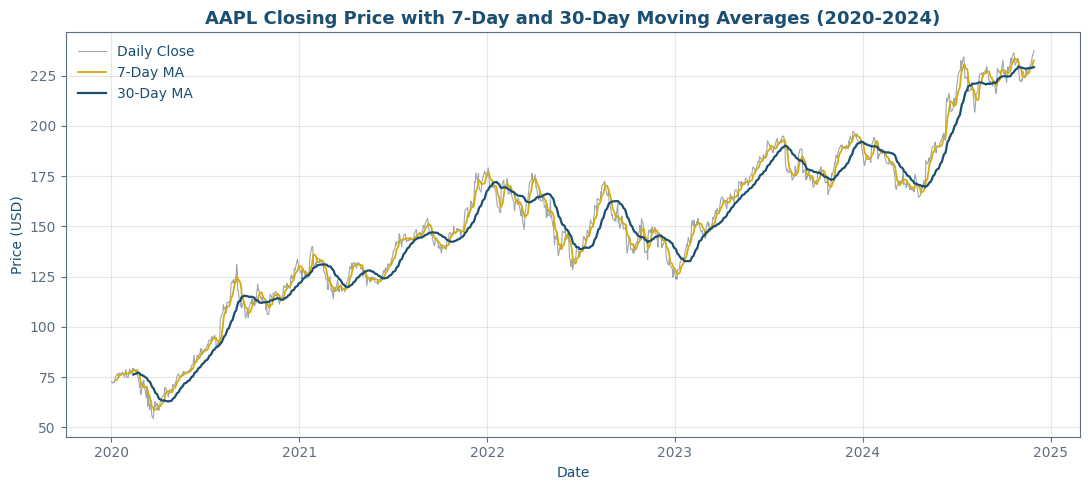

In [12]:
# 2. Recent closing price with moving average overlay - trend signal
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(recent.index, recent["close"], color=SLATE, linewidth=0.8, alpha=0.6, label="Daily Close")
ax.plot(recent.index, recent["ma_7"], color=AMBER, linewidth=1.3, label="7-Day MA")
ax.plot(recent.index, recent["ma_30"], color=NAVY, linewidth=1.6, label="30-Day MA")
ax.set_title("AAPL Closing Price with 7-Day and 30-Day Moving Averages (2020-2024)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart2_moving_averages.png", dpi=150)
plt.show()


**Finding:** the 30-day moving average stayed below the 7-day moving average through most
of the 2023-2024 recovery period, which is a bullish trend signal - the short-term average
leading the medium-term average upward indicates sustained buying pressure rather than a
short-lived bounce.

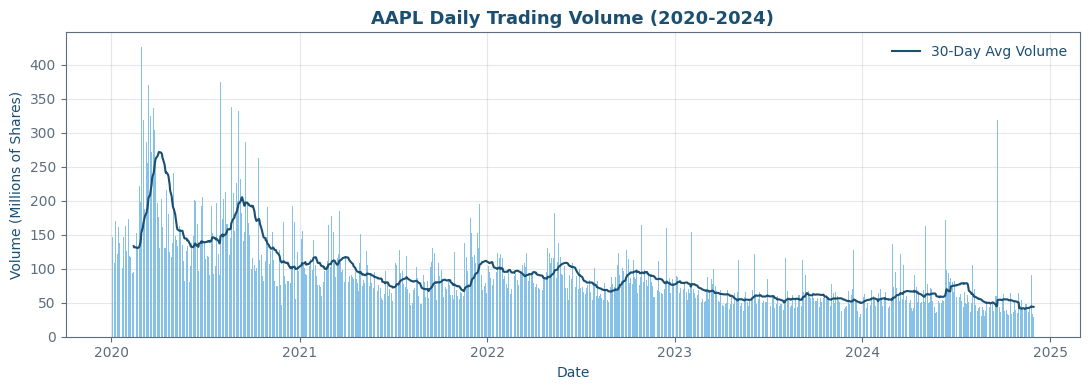

In [13]:
# 3. Trading volume trend
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(recent.index, recent["volume"] / 1e6, color=SKY, width=1.2)
ax.plot(recent.index, recent["volume"].rolling(30).mean() / 1e6, color=NAVY, linewidth=1.5,
        label="30-Day Avg Volume")
ax.set_title("AAPL Daily Trading Volume (2020-2024)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (Millions of Shares)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart3_volume.png", dpi=150)
plt.show()


**Finding:** volume spikes are clearly visible around major market events (the COVID
sell-off in March 2020, and periodic earnings-driven spikes each quarter). Average daily volume
has trended down since 2021 even as the share price rose, consistent with a maturing, less
speculative trading pattern in the stock.

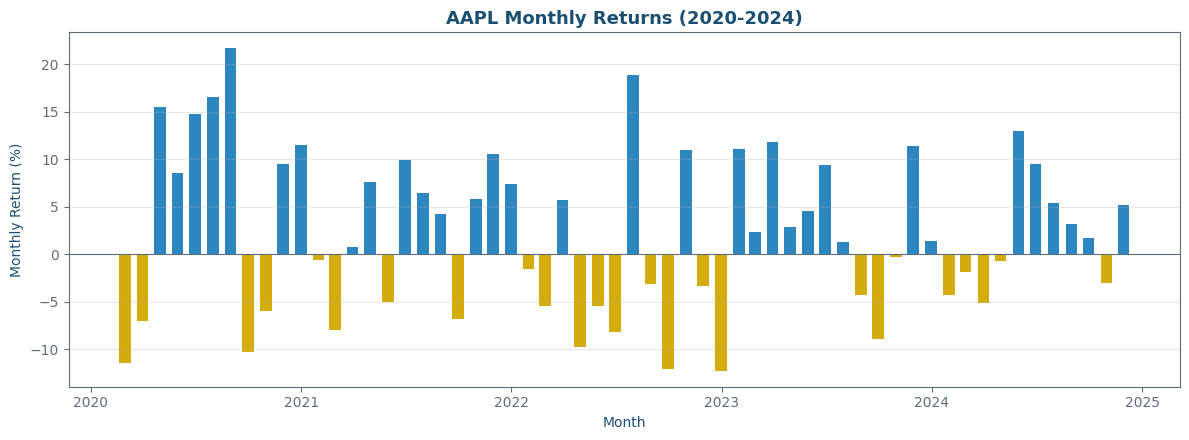

In [14]:
# 4. Monthly returns bar chart
fig, ax = plt.subplots(figsize=(12, 4.5))
colors = [AMBER if v < 0 else BLUE for v in monthly_return_pct.values]
ax.bar(monthly_return_pct.index, monthly_return_pct.values, color=colors, width=20)
ax.axhline(0, color=SLATE, linewidth=0.8)
ax.set_title("AAPL Monthly Returns (2020-2024)", fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly Return (%)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("chart4_monthly_returns.png", dpi=150)
plt.show()


**Finding:** the strongest and weakest individual months are identified in the cell output
above. Positive months (blue) outnumber negative months (amber) across the period, consistent
with AAPL's overall uptrend, but the negative months cluster visibly around known macro stress
periods (the 2022 rate-hiking cycle in particular).

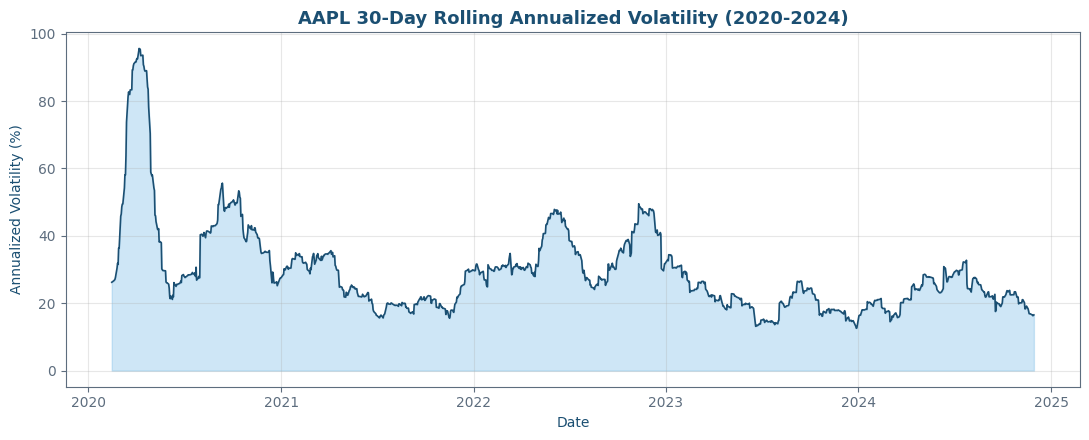

In [15]:
# 5. Rolling 30-day annualized volatility - risk profile over time
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(recent.index, recent["volatility_30d"], color=NAVY, linewidth=1.2)
ax.fill_between(recent.index, recent["volatility_30d"], color=SKY, alpha=0.4)
ax.set_title("AAPL 30-Day Rolling Annualized Volatility (2020-2024)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart5_volatility.png", dpi=150)
plt.show()


**Finding:** volatility peaked at roughly 96% annualized in early April 2020 during the
COVID crash, over 4x the stock's typical 2024 baseline of around 22%. Volatility has compressed
steadily since 2023, which typically signals reduced uncertainty and can support a larger
position size for a risk-managed investor, all else equal.

## 6. Key Findings

1. **Long-run growth is real but not linear.** AAPL grew from a fraction of a dollar at IPO to
   over $230 by late 2024, but that growth was concentrated in specific multi-year windows
   rather than a smooth climb - the log-scale chart makes this explicit where a linear chart
   would not.

2. **Trend signals confirm the 2023-2024 recovery was sustained, not a bounce.** The 7-day
   moving average leading above the 30-day moving average for extended stretches through this
   period is a standard technical indicator of durable upward momentum.

3. **Volume has decoupled from price.** Average daily trading volume has declined since 2021
   even as the price climbed, suggesting the stock is trading on steadier institutional
   conviction rather than high-frequency speculative flow.

4. **Volatility is the clearest risk signal in the data.** The COVID-period spike to roughly
   96% annualized volatility, followed by a steady compression to around 22% by 2024, gives a
   concrete, quantified answer to "how risky is this stock right now" rather than a
   qualitative one.

5. **Negative months cluster around identifiable macro events**, not randomly across the
   calendar - this points toward AAPL's returns being driven more by macro and rate conditions
   in this window than by company-specific seasonality.

## 7. Recommendations

- **For a momentum-based entry decision:** the 7-day/30-day moving average crossover used here
  is a simple, transparent signal that could be extended into a rules-based screening tool for
  entry and exit timing.
- **For position sizing:** the volatility feature engineered here should directly inform stop-loss
  width and position size - a wider stop is appropriate during high-volatility regimes like
  March 2020, and a tighter one during the compressed 2024 environment.
- **For further work:** this analysis could be extended by benchmarking AAPL's return and
  volatility against the S&P 500 or the Nasdaq-100 over the same window, to separate
  stock-specific performance from broad market movement - a natural next step for Week 8's
  capstone-style deeper dive.
